# Brain Tumor Segmentation (BraTS 2020) - Image Preprocessing

This notebook focuses on processing 3D MRI scans for tumor segmentation. The first step involves importing essential libraries for data manipulation, medical imaging, and machine learning.

### 1. Library Definitions
* **Data Handling:** `numpy` for array operations and `glob` for file path management.
* **Medical Imaging:** `nibabel` (nib) is used to read `.nii` files (NIfTI format), the standard for MRI data.
* **Deep Learning:** `tensorflow.keras` utilities to convert segmentation masks into categorical labels (One-Hot Encoding).
* **Visualization:** `matplotlib.pyplot` to display MRI slices.
* **Export:** `tifffile` to save processed slices if needed.
* **Normalization:** `MinMaxScaler` from `sklearn` to scale voxel intensities between 0 and 1, which helps the neural network converge faster.


In [1]:
import numpy as np
import nibabel as nib
import glob
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from tifffile import imwrite

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()


I0000 00:00:1776108416.798607  101023 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776108416.804287  101023 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776108416.826311  101023 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776108418.351682  101023 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_E

## 2. Directory Setup and Initial Data Exploration
In this section, we define the paths to the dataset and perform a preliminary check on a single MRI volume. BraTS 2020 folders typically contain four modalities (**FLAIR, T1, T1ce, T2**) and a segmentation mask (**Seg**).

### Data Access:
* **`TRAIN_DATASET_PATH`**: Points to the main directory containing all patient folders.
* **Loading a Sample**: We use `nib.load()` to access the **FLAIR** (Fluid Attenuated Inversion Recovery) sequence for patient `#355`.
* **`.get_fdata()`**: Converts the NIfTI object into a floating-point NumPy array.

### Initial Verification:
* **Shape**: We print the dimensions to confirm the 3D volume (standard BraTS size is $240 \times 240 \times 155$).
* **Max Intensity**: We check the maximum pixel value. Unlike standard 8-bit images (0-255), raw MRI intensities can reach several thousands, necessitating normalization for Deep Learning models.

In [2]:
TRAIN_DATASET_PATH = 'BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/'
#VALIDATION_DATASET_PATH = 'BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData'

test_image_flair=nib.load(TRAIN_DATASET_PATH + 'BraTS20_Training_355/BraTS20_Training_355_flair.nii').get_fdata()
print(test_image_flair.shape)
print(test_image_flair.max())

(240, 240, 155)
1854.603271484375


## 3. Data Normalization (Scaling)
MRI signal intensities are not standardized and can vary significantly between patients and scanners. To ensure stable and faster convergence during training, we normalize the voxel intensities.

### Why Scaling is Necessary:
* **Neural Network Stability:** Large input values can lead to "exploding gradients" or make the loss function very difficult to optimize.
* **Feature Parity:** Scaling ensures that all MRI modalities (FLAIR, T1, etc.) contribute equally to the model's learning process.

### Implementation Details:
* **Reshaping for Scikit-Learn:** Since `MinMaxScaler` expects a 2D input $(Samples, Features)$, we flatten the spatial dimensions while keeping the depth (slices) as the feature dimension.
* **Fit and Transform:** We apply the scaling so that all values typically fall within the range $[0, 1]$.
* **Reshaping Back:** Finally, we restore the original 3D shape $(240, 240, 155)$ to maintain the spatial integrity of the brain volume.

In [3]:
test_image_flair_scaled = scaler.fit_transform(test_image_flair.reshape(-1, test_image_flair.shape[-1])).reshape(test_image_flair.shape)
print(test_image_flair_scaled.shape)
print(test_image_flair_scaled.max())

(240, 240, 155)
1.0


To provide the model with a complete anatomical view, we repeat the loading and scaling process for the other three MRI sequences: **T1**, **T1ce** (T1-weighted Contrast Enhanced), and **T2**.

In [4]:
test_image_t1 = nib.load(TRAIN_DATASET_PATH + 'BraTS20_Training_355/BraTS20_Training_355_t1.nii').get_fdata()
test_image_t1 = scaler.fit_transform(test_image_t1.reshape(-1, test_image_t1.shape[-1])).reshape(test_image_t1.shape)

test_image_t1ce=nib.load(TRAIN_DATASET_PATH + 'BraTS20_Training_355/BraTS20_Training_355_t1ce.nii').get_fdata()
test_image_t1ce=scaler.fit_transform(test_image_t1ce.reshape(-1, test_image_t1ce.shape[-1])).reshape(test_image_t1ce.shape)

test_image_t2=nib.load(TRAIN_DATASET_PATH + 'BraTS20_Training_355/BraTS20_Training_355_t2.nii').get_fdata()
test_image_t2=scaler.fit_transform(test_image_t2.reshape(-1, test_image_t2.shape[-1])).reshape(test_image_t2.shape)


## 4. Loading and Preparation of Segmentation Mask

The segmentation mask (file `_seg.nii`) contains the **ground truth labels** for each voxel. In BraTS 2020, the classes are:

| Value | Tumor Region |
|-------|--------------|
| 0 | Healthy tissue (background) |
| 1 | Necrotic Core |
| 2 | Peritumoral Edema |
| 4 | Enhancing Tumor |

> **Why reassign value 4 → 3?**  
> Class `4` exists in the original annotations but is **not contiguous** (there is no class `3`). To use Keras's `to_categorical` correctly, class indices must be consecutive. We therefore replace `4` with `3` to obtain 4 consecutive classes: `{0, 1, 2, 3}`.

In [5]:

test_mask=nib.load(TRAIN_DATASET_PATH + 'BraTS20_Training_355/BraTS20_Training_355_seg.nii').get_fdata()
test_mask=test_mask.astype(np.uint8)
print(np.unique(test_mask))
test_mask[test_mask == 4] = 3 #Reassign mask values 4 to 3
print(np.unique(test_mask))

[0 1 2 4]
[0 1 2 3]


## 5. Visualization of MRI Modalities

Before any in-depth processing, it is essential to **visually verify** the loaded data. This step allows us to:

- Confirm that the NIfTI files are properly loaded and normalized (values between 0 and 1).
- Observe the contrast differences between the four modalities (**FLAIR, T1, T1ce, T2**).
- Verify spatial consistency between the images and their segmentation mask.

A **random slice** (Z-axis) is selected for display.

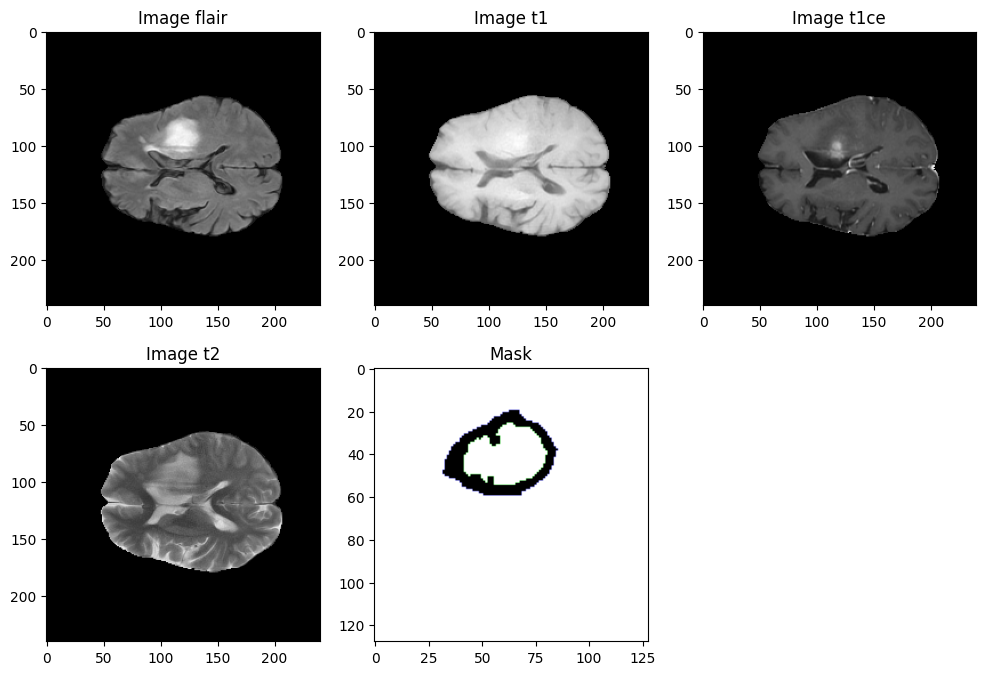

In [18]:
import random
n_slice = random.randint(0, test_mask.shape[2])
plt.figure(figsize=(12, 8))

plt.subplot(231)
plt.imshow(test_image_flair[:,:,n_slice], cmap='gray')
plt.title('Image flair')
plt.subplot(232)
plt.imshow(test_image_t1[:,:,n_slice], cmap='gray')
plt.title('Image t1')
plt.subplot(233)
plt.imshow(test_image_t1ce[:,:,n_slice], cmap='gray')
plt.title('Image t1ce')
plt.subplot(234)
plt.imshow(test_image_t2[:,:,n_slice], cmap='gray')
plt.title('Image t2')
plt.subplot(235)
plt.imshow(test_mask[:,:,n_slice])
plt.title('Mask')
plt.show()

## 6. Fusion of Modalities into a Single Tensor

To feed the neural network, the three selected modalities (**FLAIR, T1ce, T2**) are **stacked** along a 4th axis, forming a tensor of shape $240 \times 240 \times 155 \times 3$.

> **Why is T1 excluded?**  
> The non-enhanced T1 modality provides little additional information compared to T1ce and FLAIR. Its removal reduces dimensionality without significant loss of clinical information, and reduces GPU memory usage.

In [7]:
combined_x = np.stack([test_image_flair, test_image_t1ce, test_image_t2], axis=3)
print(combined_x.shape)

(240, 240, 155, 3)


## 7. Cropping of Volumes

The raw BraTS 2020 MRI volume measures $240 \times 240 \times 155$ voxels. A large portion of the edges contains only black background (air/noise), with no useful information.

### Cropping Objective
- Reduce memory usage during training.
- Obtain a size divisible by **64** (necessary for 3D convolutions in U-Net-like architectures).

### Parameters Used
```
Rows (X)     : 56 → 184  → 128 voxels
Columns (Y)  : 56 → 184  → 128 voxels  
Depth (Z)    : 13 → 141  → 128 voxels
```
The final volume is $128 \times 128 \times 128 \times 3$.

In [8]:
combined_x = combined_x[56:184, 56:184, 13:141] #Crop the images to 128x128x128 to reduce memory usage and speed up training
print(combined_x.shape)

(128, 128, 128, 3)


### Cropping of Segmentation Mask

The mask is cropped using the **same indices** as the images to maintain perfect spatial correspondence between the input volumes and labels.

In [9]:
test_mask = test_mask[56:184, 56:184, 13:141]
print(test_mask.shape)

(128, 128, 128)


## 8. Visualization After Cropping

After cropping, we verify once more that the three modalities and the mask are well-aligned and that regions of interest (tumor) are still visible in the reduced volume.

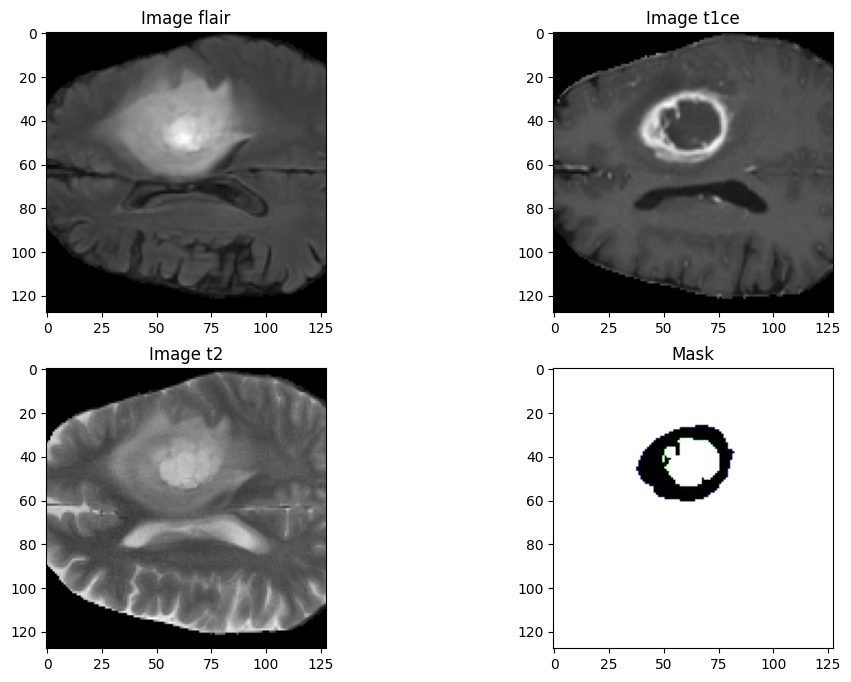

In [16]:
n_slice=random.randint(0, test_mask.shape[2])
plt.figure(figsize=(12, 8))

plt.subplot(221)
plt.imshow(combined_x[:,:,n_slice, 0], cmap='gray')
plt.title('Image flair')
plt.subplot(222)
plt.imshow(combined_x[:,:,n_slice, 1], cmap='gray')
plt.title('Image t1ce')
plt.subplot(223)
plt.imshow(combined_x[:,:,n_slice, 2], cmap='gray')
plt.title('Image t2')
plt.subplot(224)
plt.imshow(test_mask[:,:,n_slice])
plt.title('Mask')
plt.show()

## 9. Saving the Test Volume

The combined volume is saved in two formats:
- **`.tif`** : multi-page image format, useful for visual inspection with tools like ImageJ/Fiji.
- **`.npy`** : NumPy binary format, optimized for fast reloading in Python during training.

In [11]:
# save using tifffile imwrite (imsave is not imported)
imwrite('BraTS2020_TrainingData/combined255.tif', combined_x)
np.save('BraTS2020_TrainingData/combined255.npy', combined_x)

## 10. One-Hot Encoding of Mask (*to_categorical*)

The `to_categorical` function transforms the integer mask (values `0, 1, 2, 3`) into a **one-hot** representation:

$$\text{Mask}_{128 \times 128 \times 128} \xrightarrow{\text{to\_categorical}} \text{Mask}_{128 \times 128 \times 128 \times 4}$$

Each voxel is now represented by a binary vector of length 4, where only one position is `1` (the voxel's class). This representation is required for **categorical cross-entropy** loss functions used in multi-class segmentation.

In [12]:
my_img = np.load('BraTS2020_TrainingData/combined255.npy')
test_mask = to_categorical(test_mask, num_classes=4)
print(test_mask.shape)

(128, 128, 128, 4)


---

## 11. Batch Processing of the Entire Dataset

The previous steps were tested on **a single patient** (BraTS20_Training_355). This section applies the same preprocessing pipeline to **all 369 volumes** from the training dataset.

### Complete pipeline per volume
1. Load 3 NIfTI modalities (T2, T1ce, FLAIR)
2. Independent Min-Max normalization per modality
3. Load and convert mask (uint8, reassign 4→3)
4. Stack into 4D tensor + crop to 128×128×128
5. **Quality filtering** : only volumes with at least **1% of labeled voxels** are kept
6. Save images and masks as `.npy` files

In [13]:
#t1_list = sorted(glob.glob('BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/*/*t1.nii'))
t2_list = sorted(glob.glob('BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/*/*t2.nii'))
t1ce_list = sorted(glob.glob('BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/*/*t1ce.nii'))
flair_list = sorted(glob.glob('BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/*/*flair.nii'))
mask_list = sorted(glob.glob('BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/*/*seg.nii'))

Each volume generates 18 64x64x64x4 sub-volumes. 
Total 369 volumes = 6642 sub volumes

In [14]:
for img in range(len(t2_list)):   #Using t1_list as all lists are of same size
    print("Now preparing image and masks number: ", img)
      
    temp_image_t2=nib.load(t2_list[img]).get_fdata()
    temp_image_t2=scaler.fit_transform(temp_image_t2.reshape(-1, temp_image_t2.shape[-1])).reshape(temp_image_t2.shape)
   
    temp_image_t1ce=nib.load(t1ce_list[img]).get_fdata()
    temp_image_t1ce=scaler.fit_transform(temp_image_t1ce.reshape(-1, temp_image_t1ce.shape[-1])).reshape(temp_image_t1ce.shape)
   
    temp_image_flair=nib.load(flair_list[img]).get_fdata()
    temp_image_flair=scaler.fit_transform(temp_image_flair.reshape(-1, temp_image_flair.shape[-1])).reshape(temp_image_flair.shape)
        
    temp_mask=nib.load(mask_list[img]).get_fdata()
    temp_mask=temp_mask.astype(np.uint8)
    temp_mask[temp_mask==4] = 3  #Reassign mask values 4 to 3
    
    temp_combined_images = np.stack([temp_image_flair, temp_image_t1ce, temp_image_t2], axis=3)
    
    #Crop to a size to be divisible by 64 so we can later extract 64x64x64 patches. 
    #cropping x, y, and z
    temp_combined_images=temp_combined_images[56:184, 56:184, 13:141]
    temp_mask = temp_mask[56:184, 56:184, 13:141]
    
    val, counts = np.unique(temp_mask, return_counts=True)
    
    if (1 - (counts[0]/counts.sum())) > 0.01:  #At least 1% useful volume with labels that are not 0
        print("Save Me")
        temp_mask= to_categorical(temp_mask, num_classes=4)
        np.save('BraTS2020_TrainingData/input_data_3channels/images/image_'+str(img)+'.npy', temp_combined_images)
        np.save('BraTS2020_TrainingData/input_data_3channels/masks/mask_'+str(img)+'.npy', temp_mask)
        
    else:
        print("I am useless")


#Repeat the same from above for validation data folder OR
#Split training data into train and validation

"""
Code for splitting folder into train, test, and val.
Once the new folders are created rename them and arrange in the format below to be used
for semantic segmentation using data generators. 

pip install split-folders
"""
import splitfolders

input_folder = 'BraTS2020_TrainingData/input_data_3channels/'
output_folder = 'BraTS2020_TrainingData/input_data_128/'

# Split with a ratio.
# To only split into training and validation set, set a tuple to `ratio`, i.e, `(.8, .2)`.
splitfolders.ratio(input_folder, output=output_folder, seed=42, ratio=(.75, .25), group_prefix=None) # default values

Now preparing image and masks number:  0
Save Me
Now preparing image and masks number:  1
Save Me
Now preparing image and masks number:  2
Save Me
Now preparing image and masks number:  3
Save Me
Now preparing image and masks number:  4
I am useless
Now preparing image and masks number:  5
Save Me
Now preparing image and masks number:  6
Save Me
Now preparing image and masks number:  7
Save Me
Now preparing image and masks number:  8
Save Me
Now preparing image and masks number:  9
Save Me
Now preparing image and masks number:  10
Save Me
Now preparing image and masks number:  11
Save Me
Now preparing image and masks number:  12
Save Me
Now preparing image and masks number:  13
Save Me
Now preparing image and masks number:  14
Save Me
Now preparing image and masks number:  15
Save Me
Now preparing image and masks number:  16
Save Me
Now preparing image and masks number:  17
Save Me
Now preparing image and masks number:  18
Save Me
Now preparing image and masks number:  19
Save Me
Now p